In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Наложение и удаление шума

In [3]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

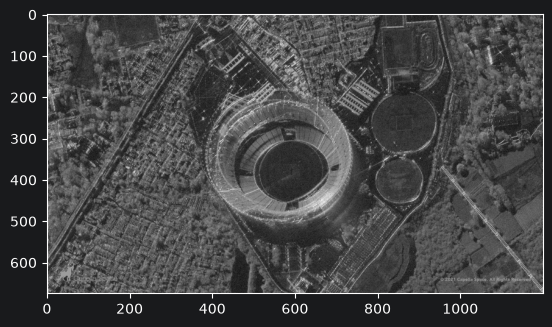

In [4]:
plt.imshow(image_gray, cmap="gray")

In [5]:
# Gaussian noise
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,  16,   0, ..., 111,   0,  80],
       [  1, 104,  68, ...,   0, 103,   0],
       [  0,   0,  51, ...,   0,   0, 145],
       ...,
       [  0,   0,  39, ..., 255,   0,  15],
       [  0,  34,   0, ...,   0,   5, 135],
       [160, 204,   0, ...,  21,   0, 109]],
      shape=(675, 1200), dtype=uint8)

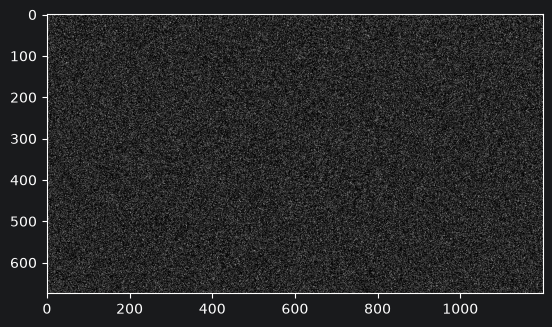

In [6]:
plt.imshow(noise_gauss, cmap="gray")

In [7]:
# Salt and pepper
noise =  np.random.randint(0, 101, size = (image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

In [8]:
bg_image = np.ones(image_gray.shape, np.uint8) * 128

In [9]:
bg_image[zeros_pixel] = 0
bg_image[ones_pixel] = 255

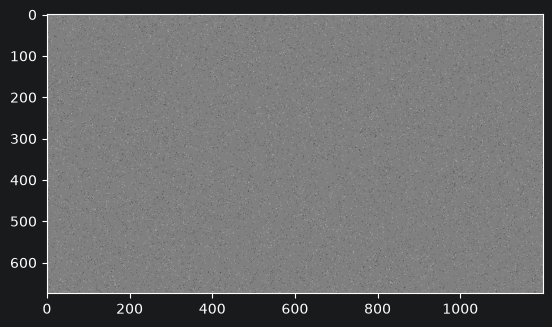

In [10]:
plt.imshow(bg_image, cmap="gray")

In [11]:
image_noise_gauss = cv2.add(image_gray,noise_gauss)

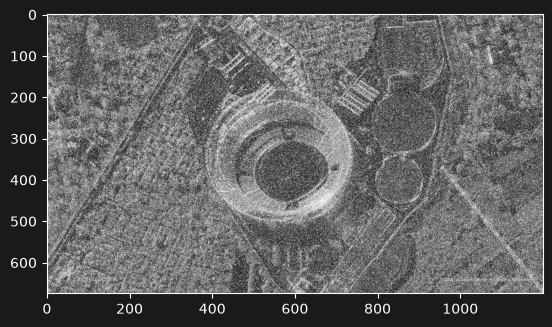

In [12]:
plt.imshow(image_noise_gauss, cmap="gray")

In [13]:
from skimage.metrics import structural_similarity, mean_squared_error
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print(mse_gauss, ssim)

4230.673058024691 0.18699266800035377


In [14]:
image_gauss_median = cv2.medianBlur(image_noise_gauss, 3)

In [15]:
mse_gauss_median = mean_squared_error(image_gray, image_gauss_median)
(ssim_gauss_median, diff) = structural_similarity(image_gray,  image_gauss_median, full=True)

In [16]:
print(mse_gauss_median, ssim_gauss_median)

1038.0453432098766 0.42824305715634176


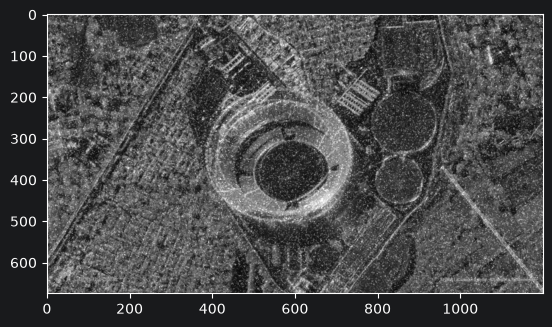

In [17]:
plt.imshow(image_gauss_median, cmap="gray")

In [18]:
import copy

image_sp = copy.deepcopy(image_gray)

image_sp[zeros_pixel] = 0
image_sp[ones_pixel] = 255

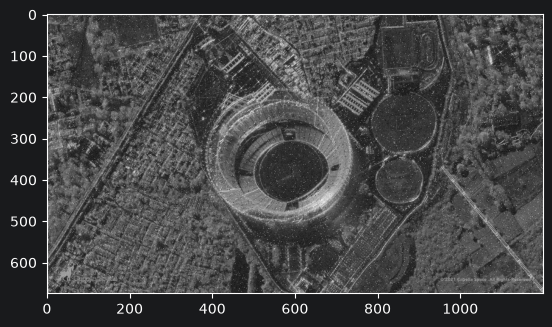

In [19]:
plt.imshow(image_sp, cmap="gray")

In [20]:
mse_sp = mean_squared_error(image_gray, image_sp)
(ssim_sp, diff) = structural_similarity(image_gray, image_sp, full=True)
print(mse_sp, ssim_sp)

382.4019987654321 0.722675499502489


In [21]:
image_sp_median = cv2.medianBlur(image_sp, 3)

In [22]:
mse_sp_median = mean_squared_error(image_gray, image_sp_median)
(ssim_sp_median, diff) = structural_similarity(image_gray, image_sp_median, full=True)
print(mse_sp_median, ssim_sp_median)

95.64317160493827 0.816376930372998


# Другие типы фильтров

In [23]:
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss,(5,5),0)

In [24]:
image_gauss_bilat = cv2.bilateralFilter(image_noise_gauss,9,75,75)

In [25]:
image_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h = 20)

In [26]:
import math

def geom(a):
    prod = 1
    for i in range(a.shape[0]):
        prod1 = 1
        for j in range(a.shape[1]):
            prod1 *= a[i,j]
        prod1 = math.pow(prod1, 1.0/9.0)
        prod *= prod1
    return prod

def proc(img, filter):
    img_res = copy.deepcopy(img)
    for i in range(0,img.shape[0] -2):
        for j in range(0,img.shape[1] -2):
            img_res[i:i+3, j:j+3] = filter(img[i:i+3, j:j+3])
    return img_res
    
res = proc(image_noise_gauss, geom)


C:\Users\roman\AppData\Local\Temp\ipykernel_39872\164976186.py:8: RuntimeWarning: overflow encountered in scalar multiply
  prod1 *= a[i,j]


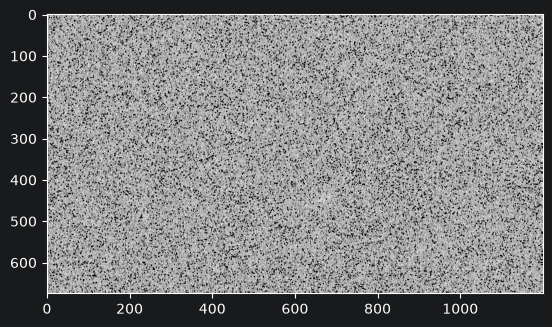

In [27]:
plt.imshow(res, cmap="gray")

In [28]:
mse_geom = mean_squared_error(image_gray, res)
(ssim_geom, diff) = structural_similarity(image_gray, res, full=True)
print(mse_geom, ssim_geom)

6551.976648148148 0.02746126776511089



# 2D свертка

In [29]:
# averaging filter
kernel_5 = np.ones((5,5),np.float32)/25
image_k5 = cv2.filter2D(image_gray,-1,kernel_5)
# blured_image = cv2.blur(img,(5,5))
image_b5 = cv2.blur(image_gray,(5,5))

In [30]:
mse_kb = mean_squared_error(image_k5, image_b5)
(ssim_kb, diff) = structural_similarity(image_k5, image_b5, full=True)
print(mse_kb, ssim_kb)

0.0 1.0


In [31]:
# Laplasian
kernel_lapl = np.array([[0,-10,0],
                        [-10,40,-10],
                        [0,-10,0]], np.float32)

In [32]:
image_lapl = cv2.filter2D(image_gray,-1,kernel_lapl) 

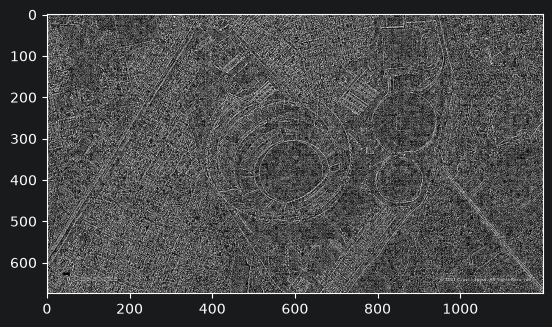

In [33]:
plt.imshow(image_lapl, cmap="gray")

In [34]:
# ДЗ 2
# Зашумить изображение при помощи шума гаусса, постоянного шума.
# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.
# Выяснить, какой фильтр показал лучший результат фильтрации шума.

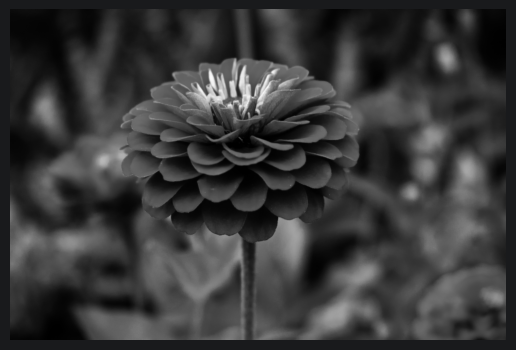

In [35]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

image_hw = cv2.imread('img.jpg')
image_hw_gray = cv2.cvtColor(image_hw, cv2.COLOR_BGR2GRAY)

plt.imshow(image_hw_gray, cmap='gray')
plt.axis('off')
plt.show()

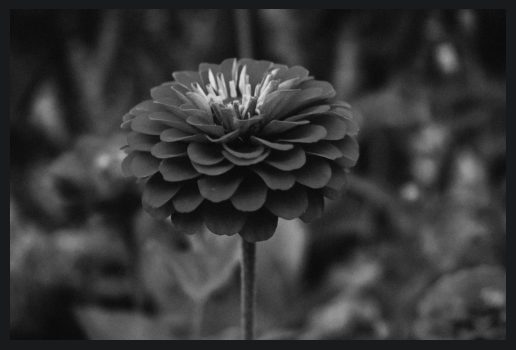

In [36]:
# Gaussian noise
mean = 0
stddev = 30

noise_gauss = np.random.normal(
    mean,
    stddev,
    image_hw_gray.shape
)

image_hw_gauss = image_hw_gray.astype(np.float32) + noise_gauss
image_hw_gauss = np.clip(image_hw_gauss, 0, 255).astype(np.uint8)

plt.imshow(image_hw_gauss, cmap='gray')
plt.axis('off')
plt.show()

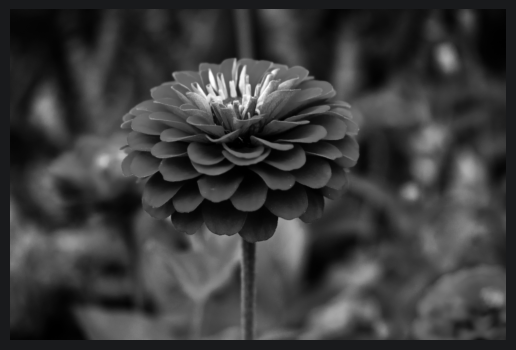

In [37]:
constant = 30

image_hw_constant = image_hw_gray.astype(np.int16) + constant
image_hw_constant = np.clip(image_hw_constant, 0, 255).astype(np.uint8)

plt.imshow(image_hw_constant, cmap='gray')
plt.axis('off')
plt.show()

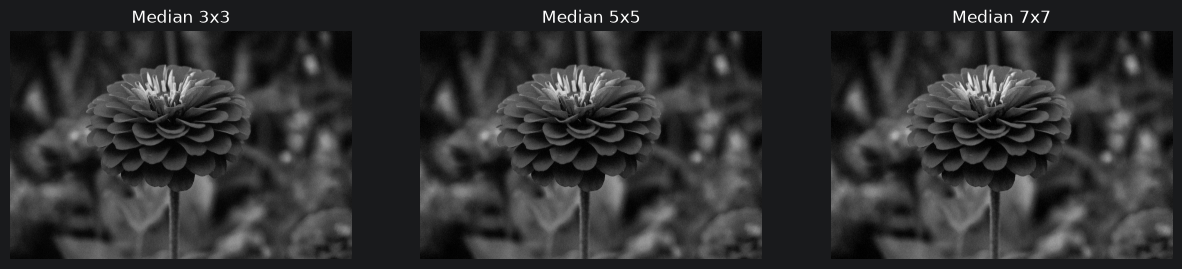

In [38]:
median_3 = cv2.medianBlur(image_hw_gauss, 3)
median_5 = cv2.medianBlur(image_hw_gauss, 5)
median_7 = cv2.medianBlur(image_hw_gauss, 7)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(median_3, cmap='gray')
plt.title('Median 3x3')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(median_5, cmap='gray')
plt.title('Median 5x5')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(median_7, cmap='gray')
plt.title('Median 7x7')
plt.axis('off')

plt.show()

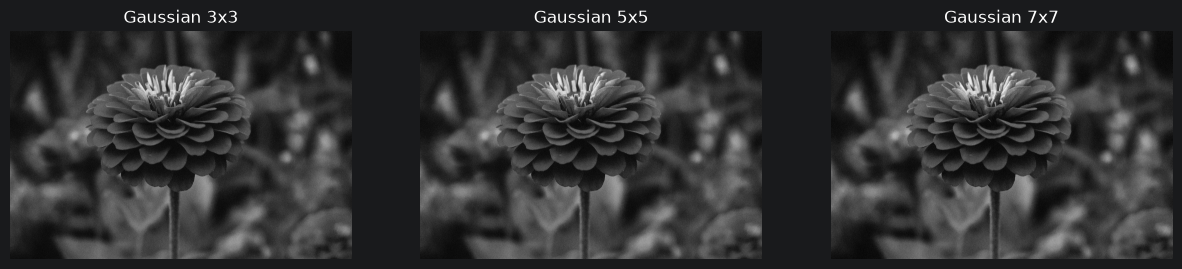

In [39]:
gauss_3 = cv2.GaussianBlur(image_hw_gauss, (3, 3), 0)
gauss_5 = cv2.GaussianBlur(image_hw_gauss, (5, 5), 0)
gauss_7 = cv2.GaussianBlur(image_hw_gauss, (7, 7), 0)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gauss_3, cmap='gray')
plt.title('Gaussian 3x3')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gauss_5, cmap='gray')
plt.title('Gaussian 5x5')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(gauss_7, cmap='gray')
plt.title('Gaussian 7x7')
plt.axis('off')

plt.show()

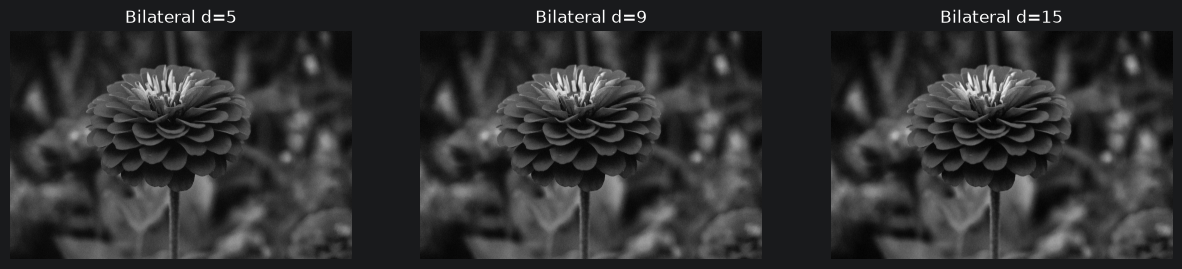

In [40]:
bilateral_1 = cv2.bilateralFilter(image_hw_gauss, 5, 30, 30)
bilateral_2 = cv2.bilateralFilter(image_hw_gauss, 9, 50, 50)
bilateral_3 = cv2.bilateralFilter(image_hw_gauss, 15, 75, 75)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(bilateral_1, cmap='gray')
plt.title('Bilateral d=5')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(bilateral_2, cmap='gray')
plt.title('Bilateral d=9')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(bilateral_3, cmap='gray')
plt.title('Bilateral d=15')
plt.axis('off')

plt.show()

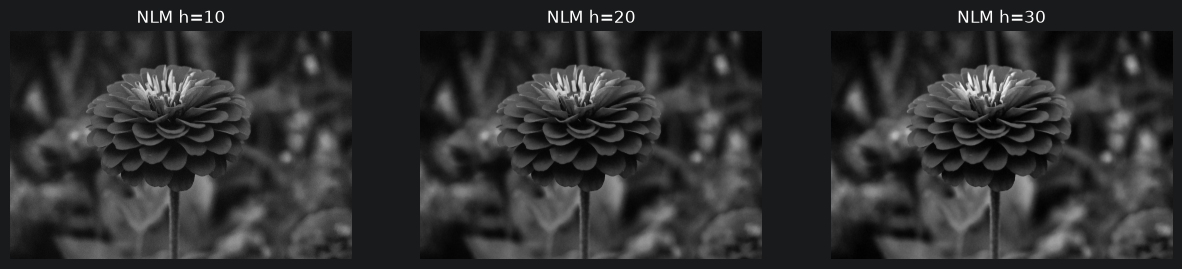

In [41]:
nlm_1 = cv2.fastNlMeansDenoising(image_hw_gauss, None, 10, 7, 21)
nlm_2 = cv2.fastNlMeansDenoising(image_hw_gauss, None, 20, 7, 21)
nlm_3 = cv2.fastNlMeansDenoising(image_hw_gauss, None, 30, 7, 21)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(nlm_1, cmap='gray')
plt.title('NLM h=10')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(nlm_2, cmap='gray')
plt.title('NLM h=20')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(nlm_3, cmap='gray')
plt.title('NLM h=30')
plt.axis('off')

plt.show()

In [42]:
from skimage.metrics import mean_squared_error, structural_similarity

filters = {
    'Median 3x3': median_3,
    'Gaussian 3x3': gauss_3,
    'Bilateral d=5': bilateral_1,
    'NLM h=10': nlm_1
}

for name, filtered in filters.items():
    mse = mean_squared_error(image_hw_gray, filtered)
    ssim = structural_similarity(image_hw_gray, filtered)

    print(f'{name}: MSE = {mse:.2f}, SSIM = {ssim:.4f}')

Median 3x3: MSE = 150.51, SSIM = 0.3491
Gaussian 3x3: MSE = 121.62, SSIM = 0.4152
Bilateral d=5: MSE = 287.73, SSIM = 0.2368
NLM h=10: MSE = 756.52, SSIM = 0.1078


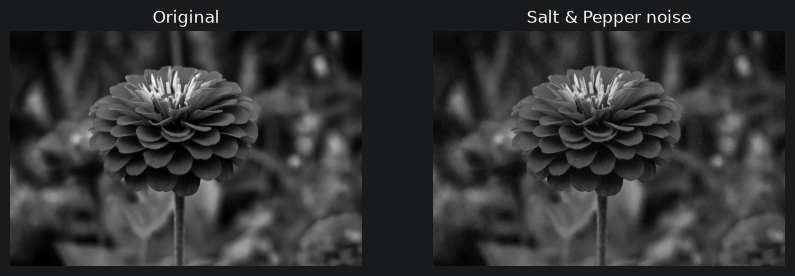

In [43]:
image_noise_sp = image_hw_gray.copy()

prob = 0.05

random_matrix = np.random.random(image_noise_sp.shape)

image_noise_sp[random_matrix < prob / 2] = 0
image_noise_sp[random_matrix > 1 - prob / 2] = 255

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_hw_gray, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image_noise_sp, cmap='gray')
plt.title('Salt & Pepper noise')
plt.axis('off')

plt.show()

In [44]:
sp_median = cv2.medianBlur(image_noise_sp, 3)
sp_gaussian = cv2.GaussianBlur(image_noise_sp, (3, 3), 0)
sp_bilateral = cv2.bilateralFilter(image_noise_sp, 5, 30, 30)
sp_nlm = cv2.fastNlMeansDenoising(image_noise_sp, None, 10, 7, 21)

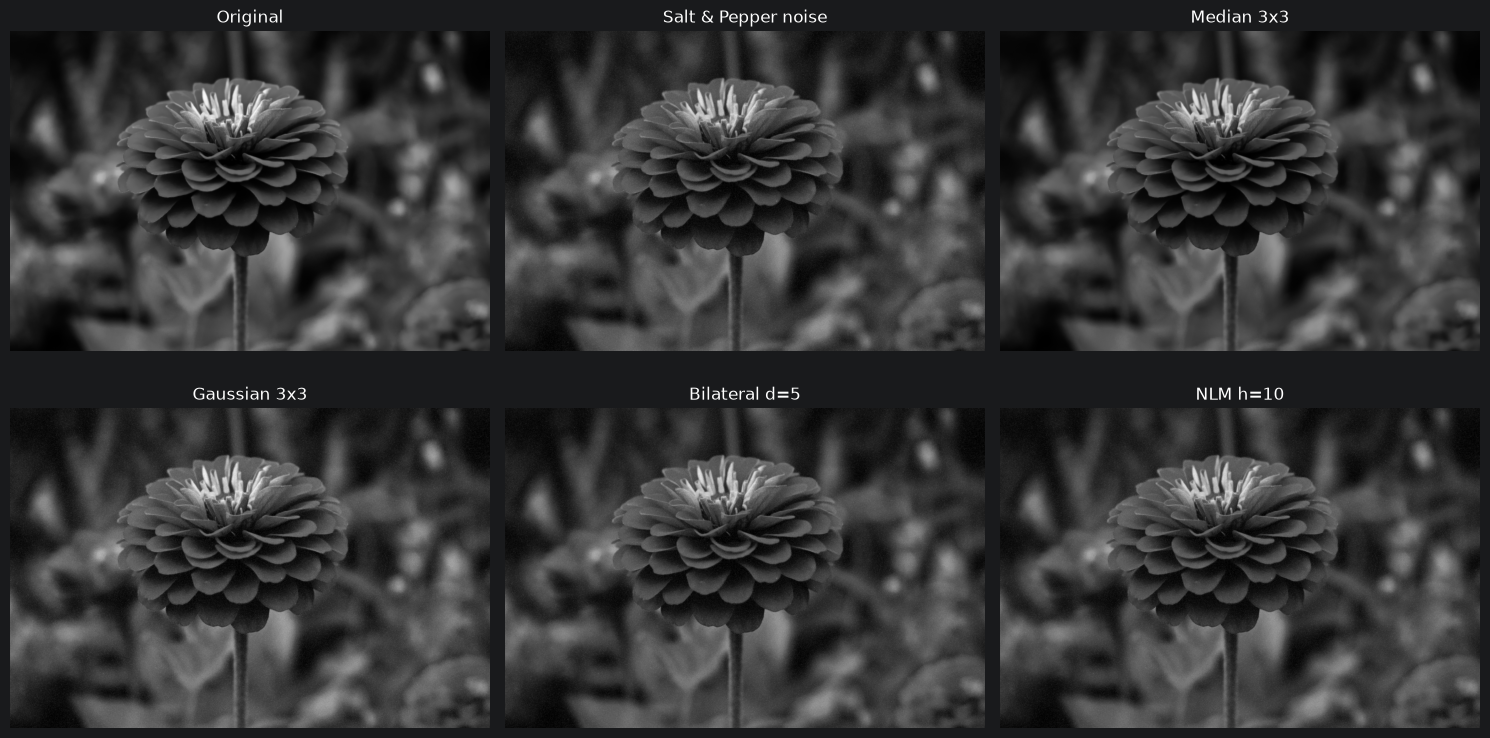

In [45]:
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(image_hw_gray, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(image_noise_sp, cmap='gray')
plt.title('Salt & Pepper noise')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(sp_median, cmap='gray')
plt.title('Median 3x3')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(sp_gaussian, cmap='gray')
plt.title('Gaussian 3x3')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(sp_bilateral, cmap='gray')
plt.title('Bilateral d=5')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(sp_nlm, cmap='gray')
plt.title('NLM h=10')
plt.axis('off')

plt.tight_layout()
plt.show()

In [46]:
filters_sp = {
    'Median 3x3': sp_median,
    'Gaussian 3x3': sp_gaussian,
    'Bilateral d=5': sp_bilateral,
    'NLM h=10': sp_nlm
}

for name, filtered in filters_sp.items():
    mse = mean_squared_error(image_hw_gray, filtered)
    ssim = structural_similarity(image_hw_gray, filtered)

    print(f'{name}: MSE = {mse:.2f}, SSIM = {ssim:.4f}')

Median 3x3: MSE = 7.96, SSIM = 0.9099
Gaussian 3x3: MSE = 177.36, SSIM = 0.4224
Bilateral d=5: MSE = 1095.70, SSIM = 0.2478
NLM h=10: MSE = 1103.06, SSIM = 0.2631


In [ ]:
Для гауссовского шума при выбранных параметрах лучший результат показал гауссовский фильтр 3×3, а для импульсного шума «соль и перец» — медианный фильтр 3×3. Это показывает, что эффективность фильтра зависит от типа шума.

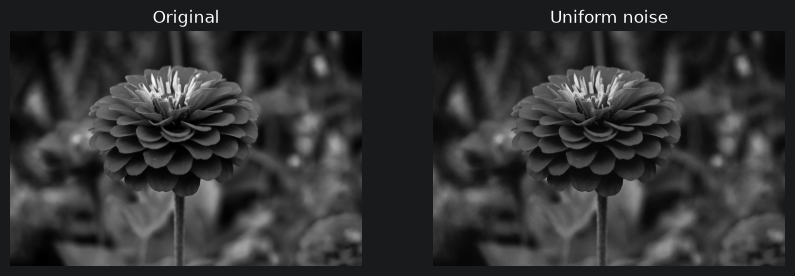

In [47]:
noise_min = -30
noise_max = 30

noise_uniform = np.random.uniform(
    noise_min,
    noise_max,
    image_hw_gray.shape
)

image_noise_uniform = np.clip(
    image_hw_gray.astype(np.float32) + noise_uniform,
    0, 255
).astype(np.uint8)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_hw_gray, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image_noise_uniform, cmap='gray')
plt.title('Uniform noise')
plt.axis('off')

plt.show()

In [48]:
uniform_median = cv2.medianBlur(image_noise_uniform, 3)
uniform_gaussian = cv2.GaussianBlur(image_noise_uniform, (3, 3), 0)
uniform_bilateral = cv2.bilateralFilter(image_noise_uniform, 5, 30, 30)
uniform_nlm = cv2.fastNlMeansDenoising(image_noise_uniform, None, 10, 7, 21)

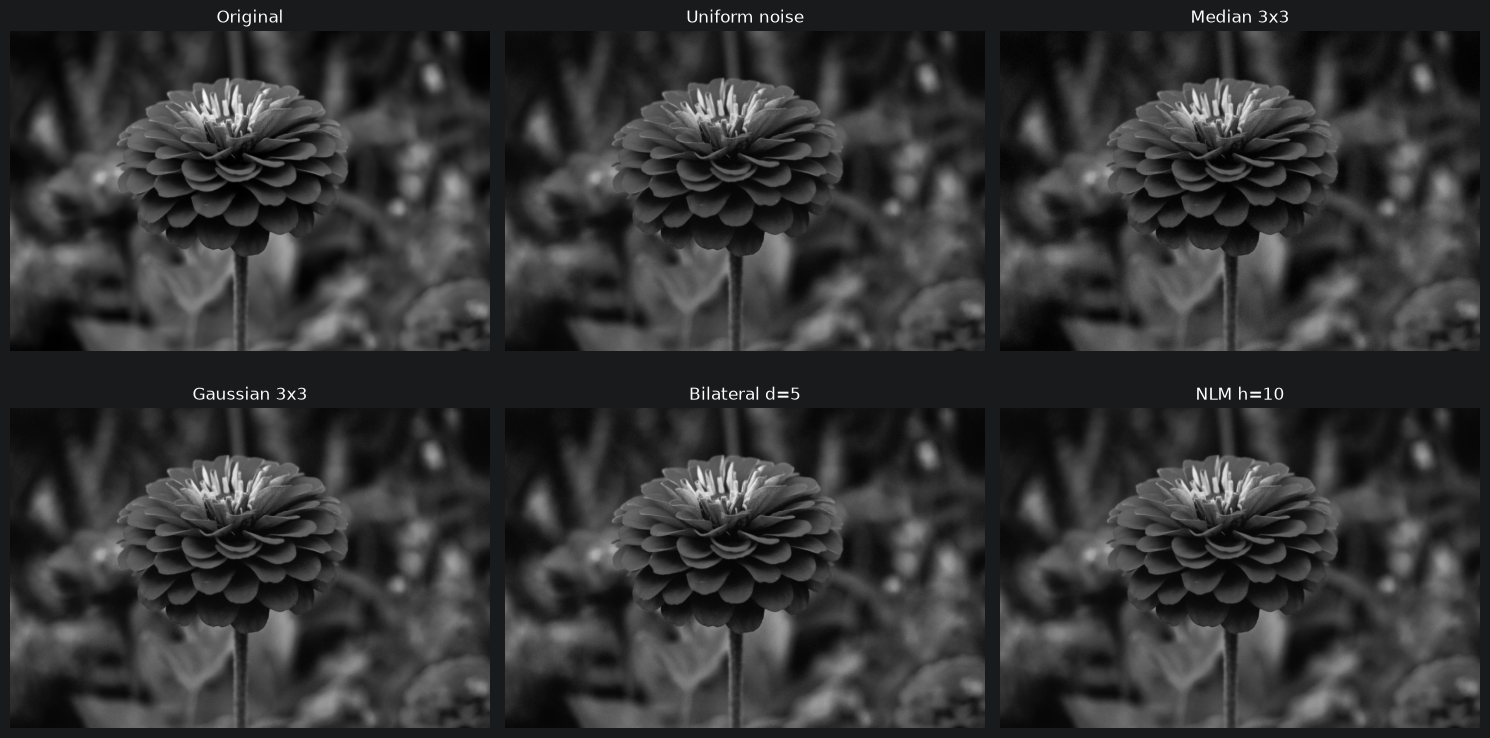

In [49]:
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(image_hw_gray, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(image_noise_uniform, cmap='gray')
plt.title('Uniform noise')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(uniform_median, cmap='gray')
plt.title('Median 3x3')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(uniform_gaussian, cmap='gray')
plt.title('Gaussian 3x3')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(uniform_bilateral, cmap='gray')
plt.title('Bilateral d=5')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(uniform_nlm, cmap='gray')
plt.title('NLM h=10')
plt.axis('off')

plt.tight_layout()
plt.show()

In [50]:
filters_uniform = {
    'Median 3x3': uniform_median,
    'Gaussian 3x3': uniform_gaussian,
    'Bilateral d=5': uniform_bilateral,
    'NLM h=10': uniform_nlm
}

for name, filtered in filters_uniform.items():
    mse = mean_squared_error(image_hw_gray, filtered)
    ssim = structural_similarity(image_hw_gray, filtered)

    print(f'{name}: MSE = {mse:.2f}, SSIM = {ssim:.4f}')

Median 3x3: MSE = 85.78, SSIM = 0.4748
Gaussian 3x3: MSE = 46.32, SSIM = 0.6338
Bilateral d=5: MSE = 54.65, SSIM = 0.5969
NLM h=10: MSE = 86.39, SSIM = 0.5195


Для шума с равномерным распределением шумовой составляющей в диапазоне от -30 до 30 при выбранных параметрах лучший результат показал гауссовский фильтр 3×3: MSE = 46.32, SSIM = 0.6338. Он обеспечивает наименьшую среднеквадратичную ошибку и наибольшее структурное сходство с нашим исходным изорбажением.